In [4]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt


In [65]:
cbb_matchups = pd.read_csv("MRegularSeasonCompactResults.csv")
cbb_matchups2025 = cbb_matchups[cbb_matchups['Season'] == 2025]

cbb_teams = pd.read_csv("MTeams.csv")

cbb_winners = pd.merge(cbb_teams, cbb_matchups2025, left_on=["TeamID"] , right_on=["WTeamID"])
cbb_winners.rename(columns = {"TeamName": "WTeamName"}, inplace = True)

cbb_w_and_l = pd.merge(cbb_winners, cbb_teams, left_on=["LTeamID"], right_on=["TeamID"])
cbb_w_and_l.rename(columns = {"TeamName": "LTeamName"}, inplace = True)
cbb_w_and_l.columns
cbb_w_and_l_teams = cbb_w_and_l[["WTeamName", "LTeamName"]]
cbb_w_and_l_teams

,WTeamName,LTeamName
0,Abilene Chr,Texas St
1,Abilene Chr,Southern Miss
2,Abilene Chr,NE Omaha
3,Abilene Chr,New Mexico St
4,Abilene Chr,TX Southern
...,...,...
5636,West Georgia,Tennessee Tech
5637,West Georgia,Austin Peay
5638,West Georgia,North Florida
5639,West Georgia,Bellarmine


In [93]:
cbb_graph = nx.DiGraph()
for i in range(1, len(cbb_teams)):
    cbb_graph.add_node(cbb_teams.loc[i]["TeamName"])

print(cbb_graph)

DiGraph with 380 nodes and 0 edges


<function matplotlib.pyplot.show(close=None, block=None)>

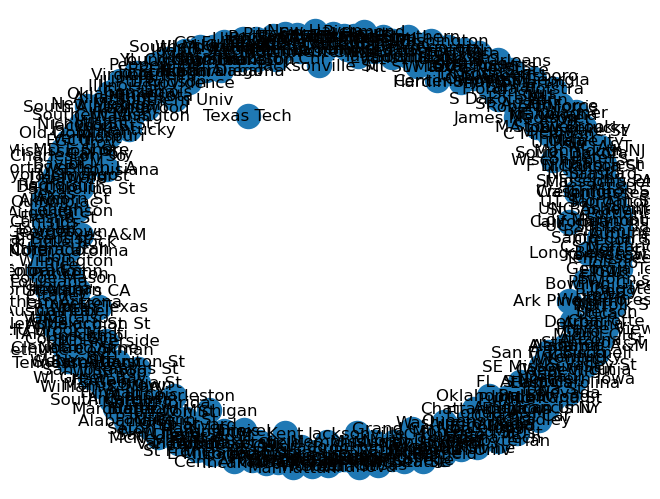

In [95]:
nx.draw(cbb_graph, with_labels = True)
plt.show

In [97]:
cbb_graph.edges

OutEdgeView([])

In [99]:
for k in range(1, len(cbb_w_and_l_teams)):
    if cbb_graph.has_edge(cbb_w_and_l_teams.loc[k]["LTeamName"], cbb_w_and_l_teams.loc[k]["WTeamName"]):
        cbb_graph[cbb_w_and_l_teams.loc[k]["LTeamName"]][cbb_w_and_l_teams.loc[k]["WTeamName"]]['weight'] += 1
    else:
        cbb_graph.add_edge(cbb_w_and_l_teams.loc[k]["LTeamName"], cbb_w_and_l_teams.loc[k]["WTeamName"], weight = 1)

print(cbb_graph)

DiGraph with 381 nodes and 4623 edges


<function matplotlib.pyplot.show(close=None, block=None)>

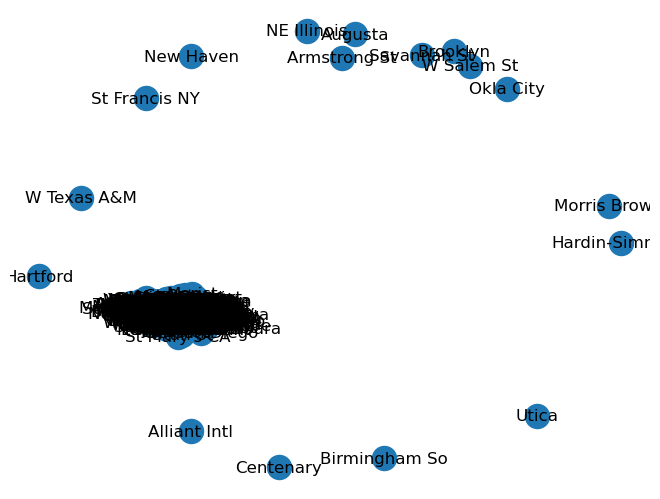

In [101]:
nx.draw(cbb_graph, with_labels = True)
plt.show

In [ ]:
cbb_graph_undirected = cbb_graph.to_dire